In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
import os

data = pd.read_csv("../data/task_offloading_dataset.csv")

X = data.drop(columns=['Offloading_Decision'])
y = data['Offloading_Decision']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [2]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
import pickle
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred = rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", accuracy)

# Save the model
rf_model_path = "../models/Random_Forest/Random_Forest_original.pkl"
with open(rf_model_path, "wb") as f:
    pickle.dump(rf_model, f)

# Get the file size of the saved model
rf_model_size = os.path.getsize(rf_model_path) / 1024  # Size in KB
print(f"Random Forest model size: {rf_model_size:.2f} KB")

# Optionally, reduce the model size by decreasing estimators
small_rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
small_rf_model.fit(X_train, y_train)

# Save the smaller Random Forest model
small_rf_model_path = "../models/Random_Forest/Random_Forest_reduced.pkl"
with open(small_rf_model_path, "wb") as f:
    pickle.dump(small_rf_model, f)

# Get the file size of the smaller model
small_rf_model_size = os.path.getsize(small_rf_model_path) / 1024  # Size in KB
print(f"Smaller Random Forest model size: {small_rf_model_size:.2f} KB")
print(f"Reduction in size: {rf_model_size - small_rf_model_size:.2f} KB ({((rf_model_size - small_rf_model_size) / rf_model_size) * 100:.2f}%)")

# Evaluate the smaller model's accuracy
small_y_pred = small_rf_model.predict(X_test)
small_accuracy = accuracy_score(y_test, small_y_pred)
print(f"Smaller Random Forest Accuracy: {small_accuracy:.4f}")

Random Forest Accuracy: 0.9983205093153146
Random Forest model size: 16741.87 KB
Smaller Random Forest model size: 1766.90 KB
Reduction in size: 14974.96 KB (89.45%)
Smaller Random Forest Accuracy: 0.9969


In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print the results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

print("Classification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Accuracy: 0.9983205093153146
Precision: 0.9983205093153146
Recall: 0.9983205093153146
F1-Score: 0.9983205093153146
Classification Report:
                precision    recall  f1-score   support

   Edge Cloud       1.00      1.00      1.00     17660
Mobile Device       1.00      1.00      1.00     33546

     accuracy                           1.00     51206
    macro avg       1.00      1.00      1.00     51206
 weighted avg       1.00      1.00      1.00     51206



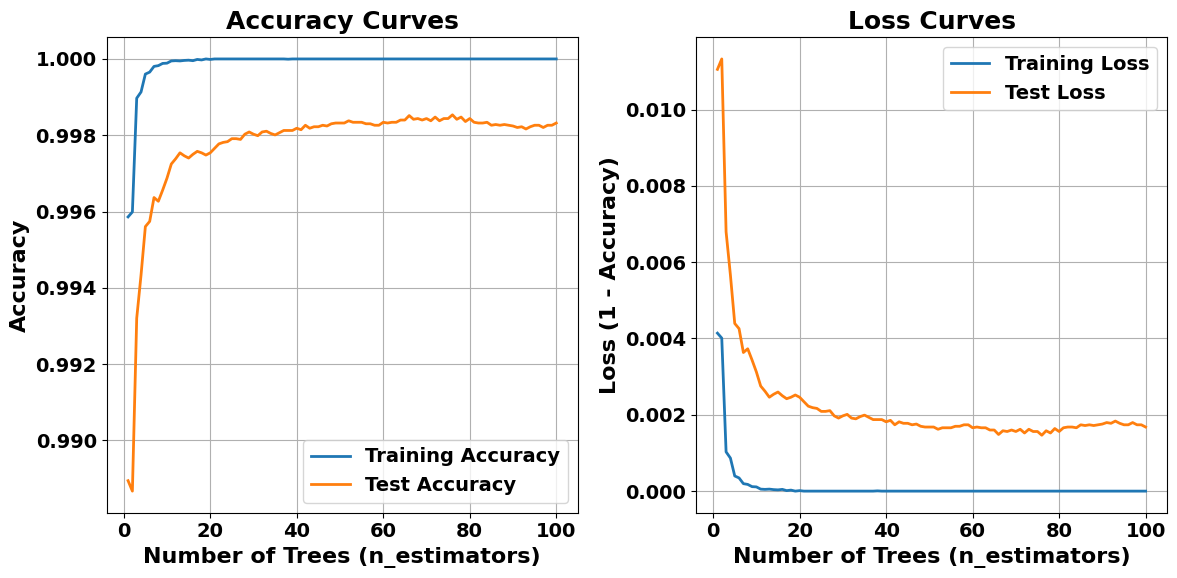

In [5]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Assuming X_train, X_test, y_train, y_test are already defined
# Range of n_estimators to test
n_estimators_range = range(1, 101)  # Vary from 1 to 100 trees
train_accuracies = []
test_accuracies = []

for n in n_estimators_range:
    rf_model = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_model.fit(X_train, y_train)

    # Evaluate on training and test data
    train_accuracies.append(accuracy_score(y_train, rf_model.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, rf_model.predict(X_test)))

# Calculate "loss" as 1 - accuracy
train_losses = [1 - acc for acc in train_accuracies]
test_losses = [1 - acc for acc in test_accuracies]

# Set font properties globally
plt.rcParams.update({
    'font.size': 14,       # Larger font size
    'font.weight': 'bold'  # Bold text
})

# Plot accuracy curves
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(n_estimators_range, train_accuracies, label='Training Accuracy', linewidth=2)
plt.plot(n_estimators_range, test_accuracies, label='Test Accuracy', linewidth=2)
plt.xlabel('Number of Trees (n_estimators)', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=16, fontweight='bold')
plt.title('Accuracy Curves', fontsize=18, fontweight='bold')
plt.legend(fontsize=14)
plt.grid(True)

# Plot loss curves
plt.subplot(1, 2, 2)
plt.plot(n_estimators_range, train_losses, label='Training Loss', linewidth=2)
plt.plot(n_estimators_range, test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Number of Trees (n_estimators)', fontsize=16, fontweight='bold')
plt.ylabel('Loss (1 - Accuracy)', fontsize=16, fontweight='bold')
plt.title('Loss Curves', fontsize=18, fontweight='bold')
plt.legend(fontsize=14)
plt.grid(True)

plt.tight_layout()
plt.show()
